In [33]:
from collections import defaultdict
from typing import Callable, Optional
import csv
import pandas as pd
import os
import utils

import utils


def get_mean_for_combinations(df: pd.DataFrame, 
                       independent_variables: list, 
                       dependent_variable: str) -> pd.DataFrame:

    # ensure all the columns are present in the df
    for col in independent_variables+[dependent_variable]:
        if col not in df:
            raise Exception(f"The column {col} is not in the dataframe\n\t(columns are {list(df.columns)})")
    assert(all(col in df for col in independent_variables))
    assert(dependent_variable in dependent_variable)
    
    grouped = df.groupby(independent_variables)[dependent_variable].mean().reset_index()
    
    return grouped
    
    

In [21]:
run_location = r"/Users/gian/Desktop/CondorResults/VDT/compareown/run3/"

In [22]:




location = os.path.join(run_location, "results.csv")

accuracy_data = pd.read_csv(location)

#headers = "kind,depth,ps_budget,ps_population,avoid_ancestors,metrics,problem,pRef_method,mse,mae,r_sq,evs"

In [23]:
independent_variables = ["ps_budget", "pRef_method", "metrics"]
dependent_variable = "r_sq"

for problem in accuracy_data["problem"].unique():
    print(f"For the problem {problem}")
    rows_with_right_problem = accuracy_data[accuracy_data["problem"] == problem]
    tabulated = get_mean_for_combinations(rows_with_right_problem, independent_variables, dependent_variable)
    tabulated.sort_values(by=dependent_variable, ascending=False, inplace=True)
    
    display(tabulated)


For the problem SAT_S


,ps_budget,pRef_method,metrics,r_sq
0,5000,GA,variance,0.524312
2,5000,uniform,variance,0.383605
1,5000,GA,variance estimated_atomicity,0.367406
3,5000,uniform,variance estimated_atomicity,0.338104


For the problem SAT_M


,ps_budget,pRef_method,metrics,r_sq
0,5000,GA,variance,0.774533
1,5000,GA,variance estimated_atomicity,0.544445
2,5000,uniform,variance,0.159076
3,5000,uniform,variance estimated_atomicity,0.094766


For the problem SAT_L


...

,ps_budget,pRef_method,metrics,r_sq
0,5000,GA,variance,0.869218
1,5000,GA,variance estimated_atomicity,0.755519
2,5000,uniform,variance,-0.004891
3,5000,uniform,variance estimated_atomicity,-0.008113


For the problem GC_L


,ps_budget,pRef_method,metrics,r_sq
0,5000,GA,variance,0.822190
1,5000,GA,variance estimated_atomicity,0.706412
2,5000,uniform,variance,-0.004283
3,5000,uniform,variance estimated_atomicity,-0.006655


For the problem BT


,ps_budget,pRef_method,metrics,r_sq
0,5000,GA,variance,0.894062
1,5000,GA,variance estimated_atomicity,0.759958
2,5000,uniform,variance,0.112256
3,5000,uniform,variance estimated_atomicity,0.052019


,ps_budget,pRef_method,metrics,problem,r_sq,overall_average
0,5000,GA,variance,BT,0.894062,22.523831
1,5000,GA,variance,GC_L,0.822190,16.953922
2,5000,GA,variance,GC_S,0.869218,19.871060
3,5000,GA,variance,SAT_L,0.855904,22.359845
4,5000,GA,variance,SAT_M,0.774533,13.494949
5,5000,GA,variance,SAT_S,0.524312,5.403851
6,5000,GA,variance estimated_atomicity,BT,0.759958,2.011795
7,5000,GA,variance estimated_atomicity,GC_L,0.706412,2.031023
8,5000,GA,variance estimated_atomicity,GC_S,0.755519,2.088114
9,5000,GA,variance estimated_atomicity,SAT_L,0.646538,2.105769


for the problem BT


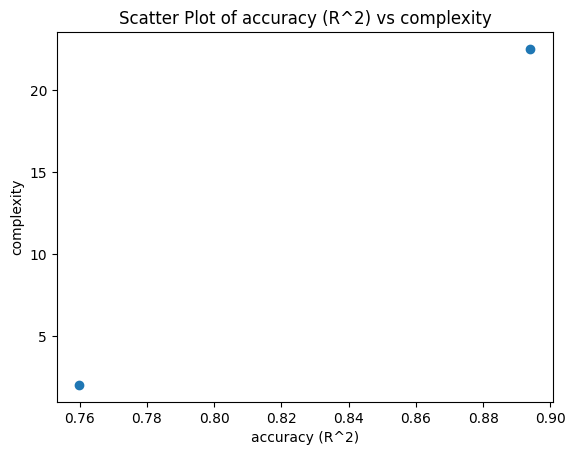

for the problem GC_L


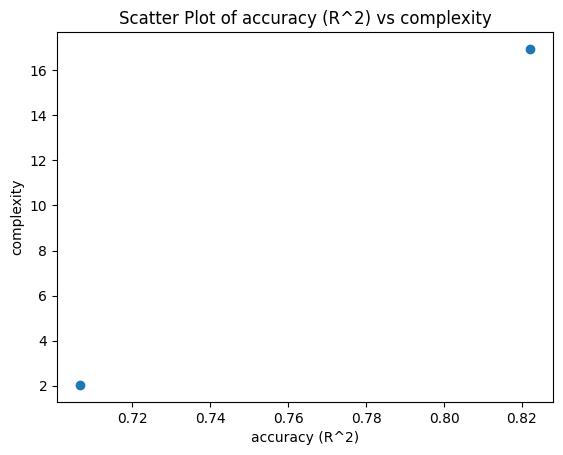

for the problem GC_S


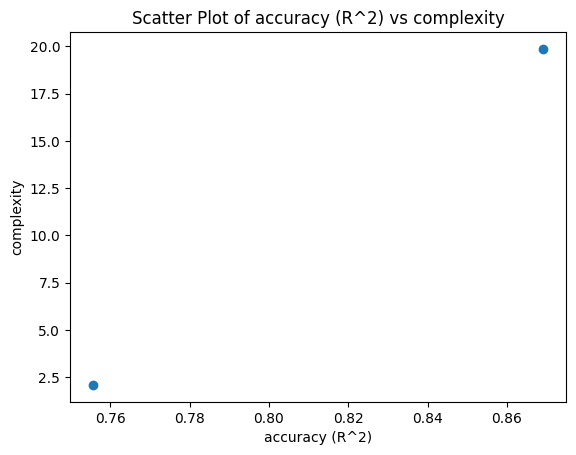

for the problem SAT_L


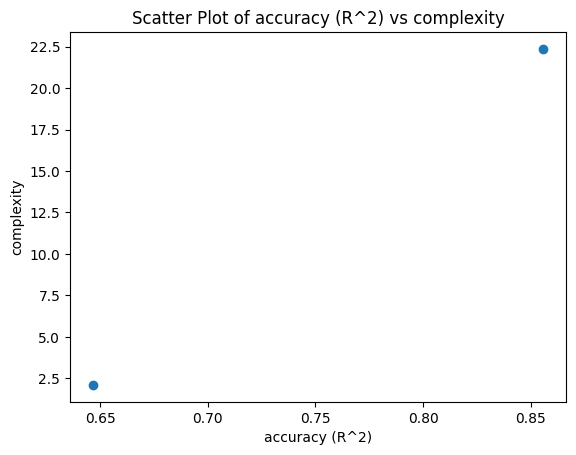

for the problem SAT_M


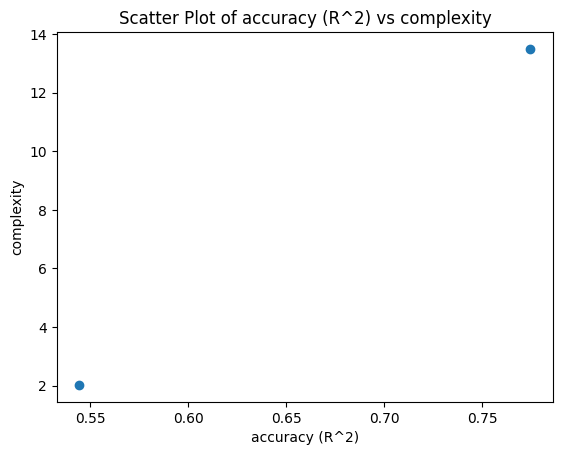

for the problem SAT_S


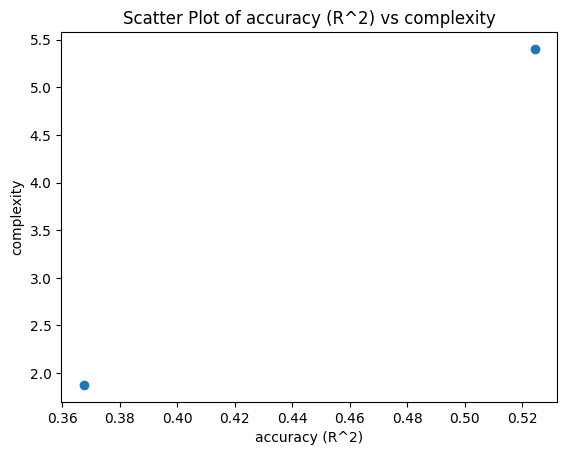

In [36]:
tree_data_location = os.path.join(run_location, "tree_data.csv")
tree_data = pd.read_csv(tree_data_location)


all_indep_vars = independent_variables+["problem"]

tabulated_accuracy_results = get_mean_for_combinations(accuracy_data, 
                                                       all_indep_vars, 
                                                       "r_sq")
tabulated_tree_results = get_mean_for_combinations(tree_data, 
                                                   all_indep_vars, 
                                                   "overall_average")

matched = tabulated_accuracy_results.merge(tabulated_tree_results, on=all_indep_vars)
matched = matched[matched["pRef_method"] == "GA"]

display(matched)


for problem in matched["problem"].unique():
    with_correct_problem = matched[matched["problem"]==problem]
    print(f"for the problem {problem}")
    utils.simple_scatterplot(x_label="accuracy (R^2)",
                             y_label="complexity",
                             xs = with_correct_problem["r_sq"],
                             ys = with_correct_problem["overall_average"])





